# Outlier assessment

In [1]:
from pathlib import Path
import multiprocessing
import shutil
import pandas as pd

from survey_medley_code.analysis_provenance import log_provenance
from survey_medley_code.config_loader import load_config
from survey_medley_code.outlier_detection_optimized import (
    generate_all_data_summaries_parallel,
)

In [2]:
cfg = load_config()

data_root = (
    cfg.output_root
    / 'within_subject_brain_behavior_by_questionnaire/adjusted_within_subject_results'
)

In [3]:
# Get all subdirectories
all_dirs = [d for d in data_root.iterdir() if d.is_dir()]
subids = [d.name for d in all_dirs if d.name.isdigit() and len(d.name) == 3]
subids.sort()

contrast_names = [
    'brief',
    'upps',
    'grit',
    'future_time',
    'impulsive_venture',
]

In [4]:
dict_list = []

for contrast_name in contrast_names:
    print(contrast_name)
    subids_loop = []
    nifti_paths_loop = []
    for subid in subids:
        contrast_name = contrast_name
        pattern = f'{subid}/{contrast_name}_behavioral_measures_effect_size_sub_{subid}.nii.gz'
        sub_nifti_paths = list(data_root.glob(pattern))
        if len(sub_nifti_paths) == 1:
            subids_loop.append(subid)
            nifti_paths_loop.append(sub_nifti_paths[0])
        else:
            print(f'sub {subid} had {len(sub_nifti_paths)} files for {contrast_name}')
    data_dict_loop = {
        'main_title': contrast_name,
        'nifti_paths': nifti_paths_loop,
        'image_labels': subids_loop,
        'data_type_label': 'contrast estimate',
    }
    dict_list.append(data_dict_loop)

brief
upps
grit
future_time
impulsive_venture
sub 061 had 0 files for impulsive_venture
sub 373 had 0 files for impulsive_venture
sub 483 had 0 files for impulsive_venture
sub 495 had 0 files for impulsive_venture
sub 497 had 0 files for impulsive_venture
sub 499 had 0 files for impulsive_venture
sub 512 had 0 files for impulsive_venture
sub 513 had 0 files for impulsive_venture
sub 541 had 0 files for impulsive_venture
sub 553 had 0 files for impulsive_venture
sub 558 had 0 files for impulsive_venture
sub 561 had 0 files for impulsive_venture
sub 573 had 0 files for impulsive_venture
sub 577 had 0 files for impulsive_venture
sub 581 had 0 files for impulsive_venture
sub 585 had 0 files for impulsive_venture
sub 588 had 0 files for impulsive_venture
sub 591 had 0 files for impulsive_venture
sub 596 had 0 files for impulsive_venture
sub 601 had 0 files for impulsive_venture
sub 602 had 0 files for impulsive_venture
sub 605 had 0 files for impulsive_venture
sub 607 had 0 files for impuls

In [5]:
n_cpus = multiprocessing.cpu_count()
print(f'Detected {n_cpus} CPUs')

n_workers = min(n_cpus, 20)

Detected 32 CPUs


In [6]:
outlier_root = data_root / 'outlier_assessment'
shutil.rmtree(outlier_root, ignore_errors=True)
outlier_root.mkdir(parents=True, exist_ok=True)

this_notebook = '/oak/stanford/groups/russpold/data/uh2/aim1/analysis_code/survey_medley_code/analyses/within_subject_brain_behavior_by_questionnaire/brain_behavior_within_subject_by_questionnaire.ipynb'

log_provenance(outlier_root, settings={'notebook_file': this_notebook})

generate_all_data_summaries_parallel(
    dict_list, n_std=3, output_dir=outlier_root, n_workers=n_workers
)

Finished impulsive_venture
Finished brief
Finished grit
Finished upps
Finished future_time
PDF saved to /oak/stanford/groups/russpold/data/uh2/aim1/derivatives/survey_medley_results/within_subject_brain_behavior_by_questionnaire/adjusted_within_subject_results/outlier_assessment/outlier_analysis.pdf
All done! PDF saved to /oak/stanford/groups/russpold/data/uh2/aim1/derivatives/survey_medley_results/within_subject_brain_behavior_by_questionnaire/adjusted_within_subject_results/outlier_assessment/outlier_analysis.pdf


In [7]:
outlier_output = pd.read_csv(
    outlier_root / 'percent_outlier_data.csv', dtype={'subject_label': str}
)

In [8]:
for contrast, df_group in outlier_output.groupby('contrast_name'):
    # Save "good" subjects (< 8) to a text file
    good_subjects = df_group[df_group['image_outlier_percentage'] < 8]['subject_label']
    txt_path = outlier_root / f'subjects_outlier_percent_lt_8_contrast_{contrast}.txt'
    good_subjects.to_csv(txt_path, index=False, header=False)

## Group analysis

Run the within-questionnaire group averages.

In [9]:
from nilearn import plotting
from nilearn.glm.second_level import SecondLevelModel
import glob
import nibabel as nf

In [10]:
def second_level_model_group_averages(bold_files, contrast):
  # extract only the files for the contrast
  contrast_bold_files = [file for file in bold_files if contrast in file]

  design_matrix = pd.DataFrame(
      [1] * len(contrast_bold_files),
      columns=['intercept'],
  )
  model = SecondLevelModel(n_jobs=2)
  model.fit(contrast_bold_files, design_matrix=design_matrix)
  z_map = model.compute_contrast('intercept', output_type='z_score')
  return z_map

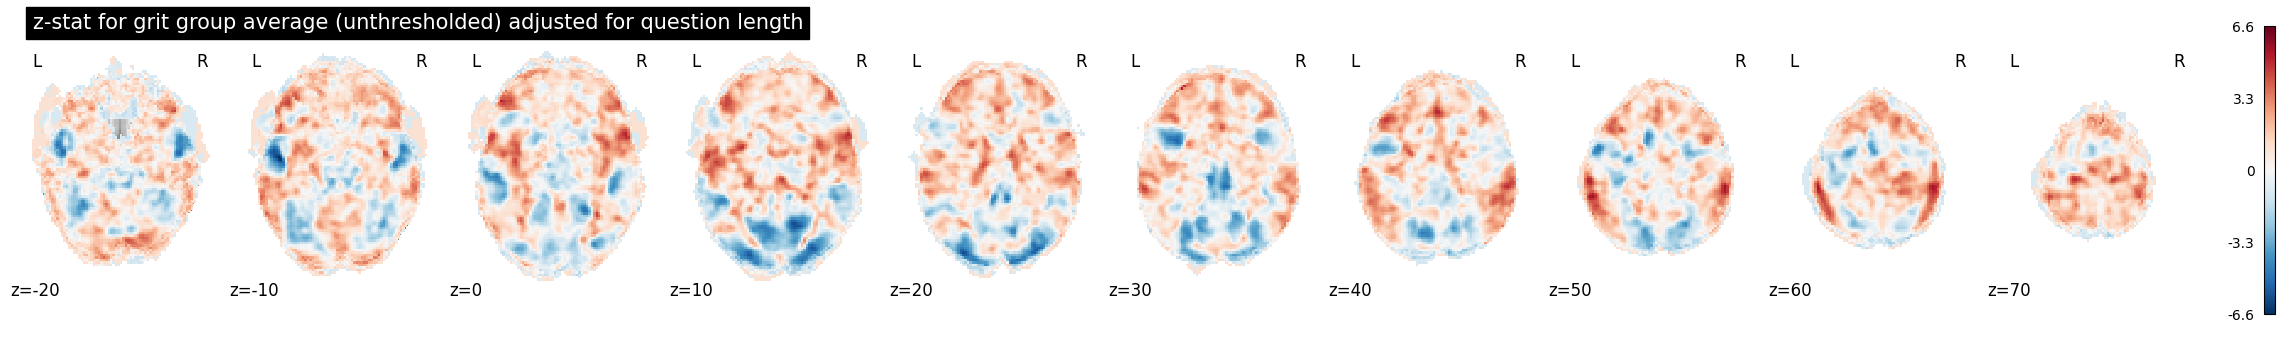

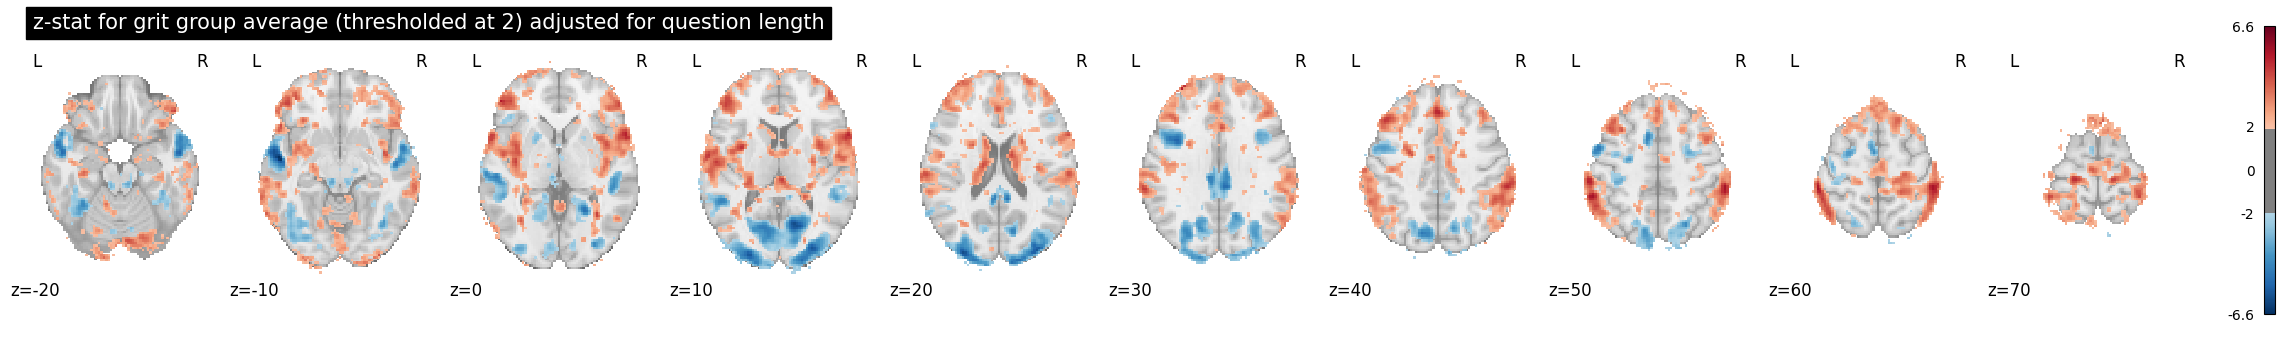

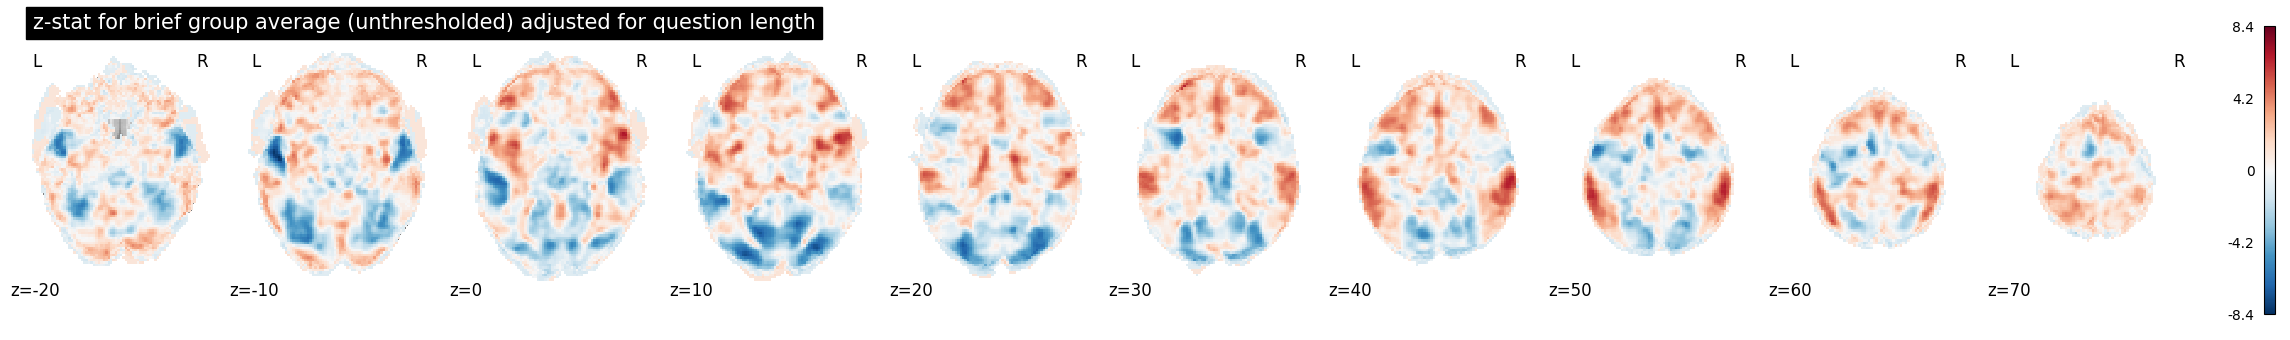

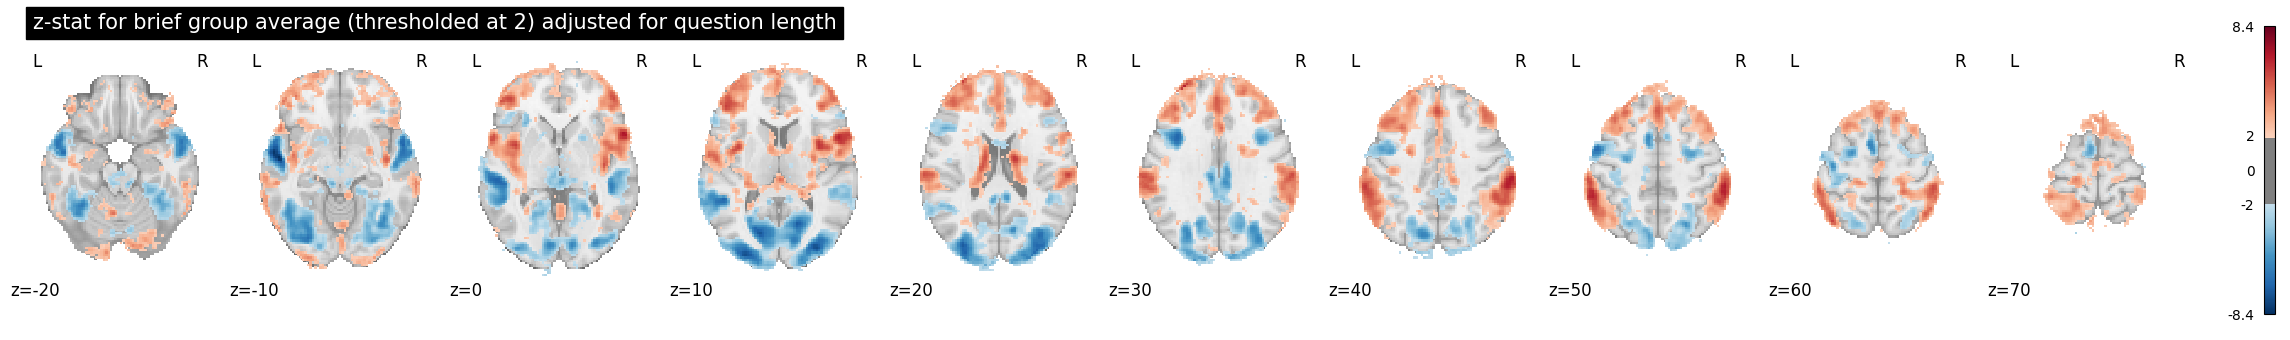

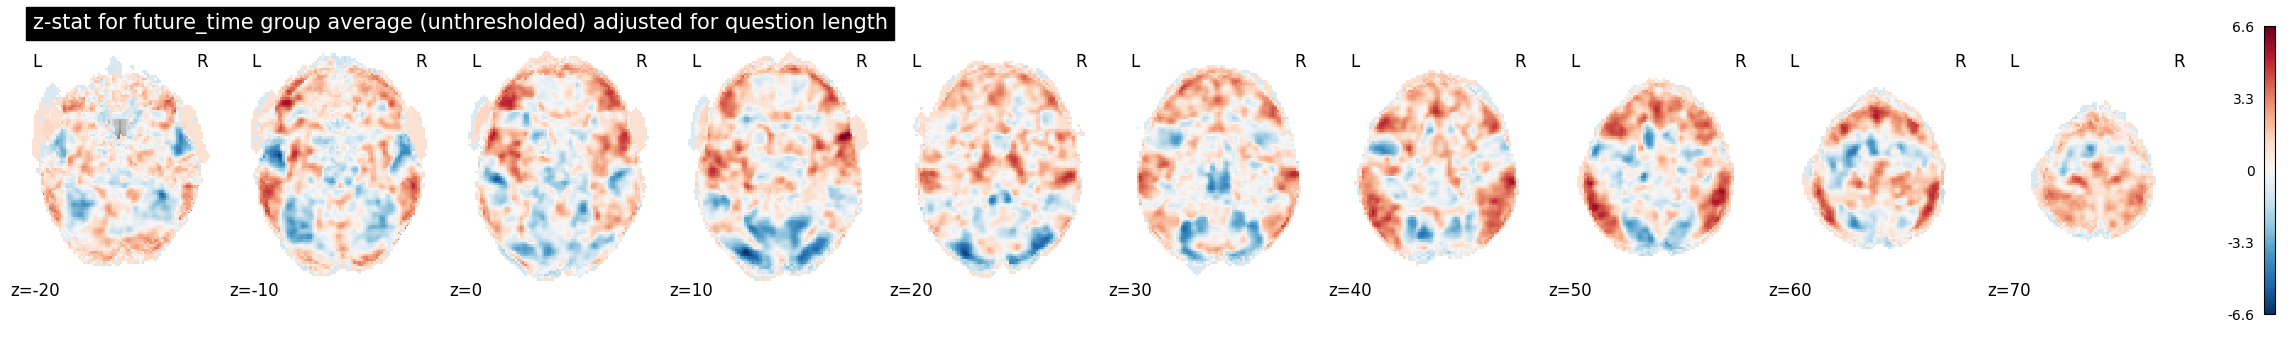

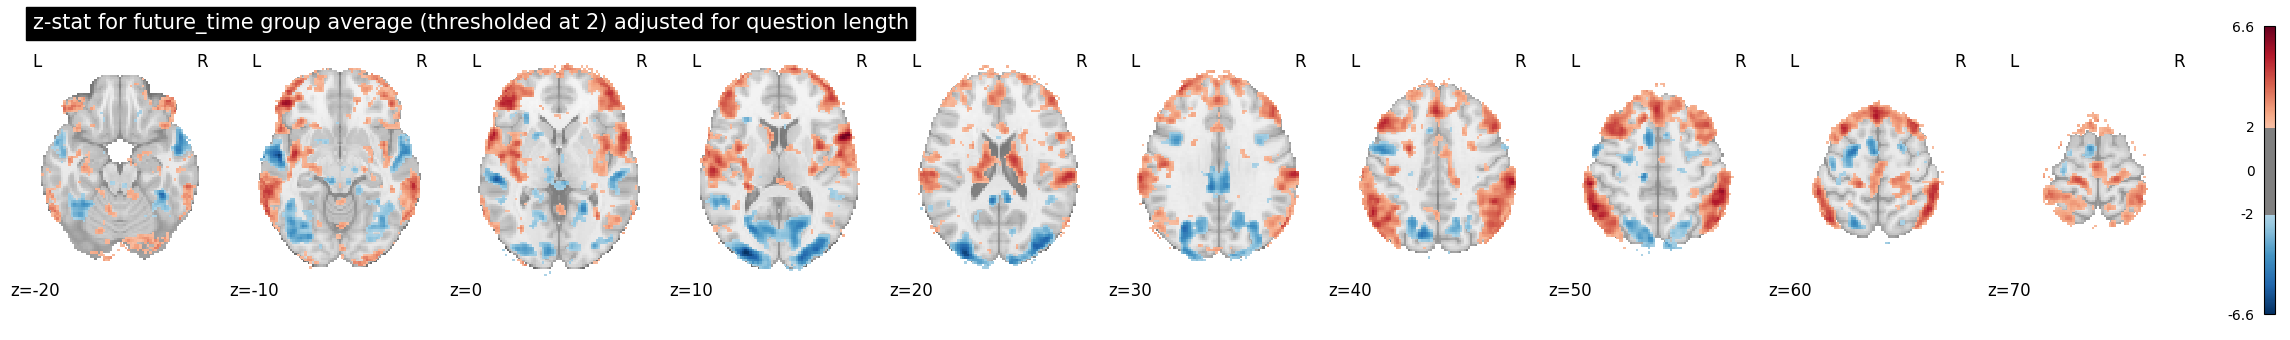

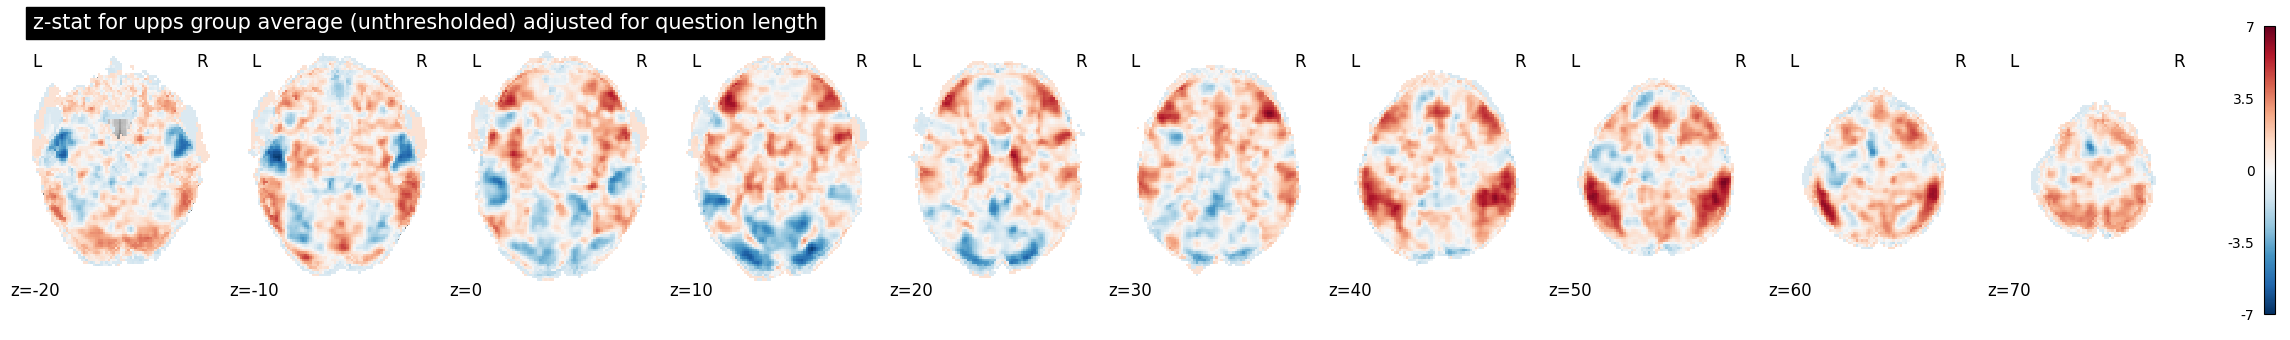

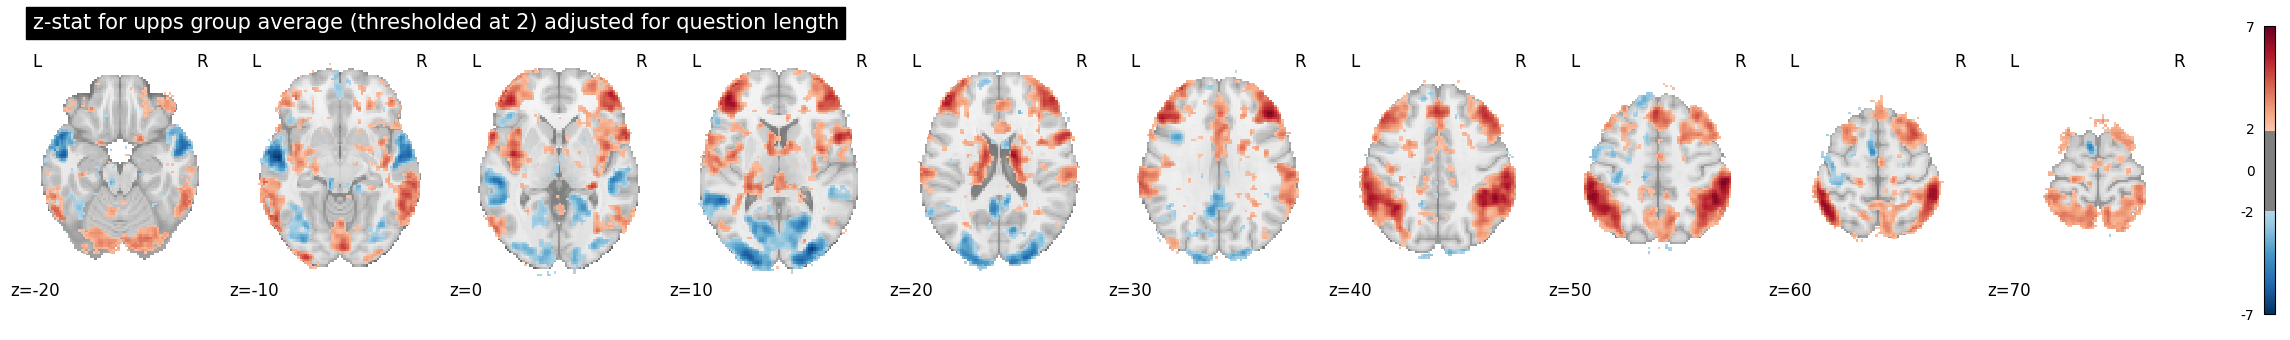

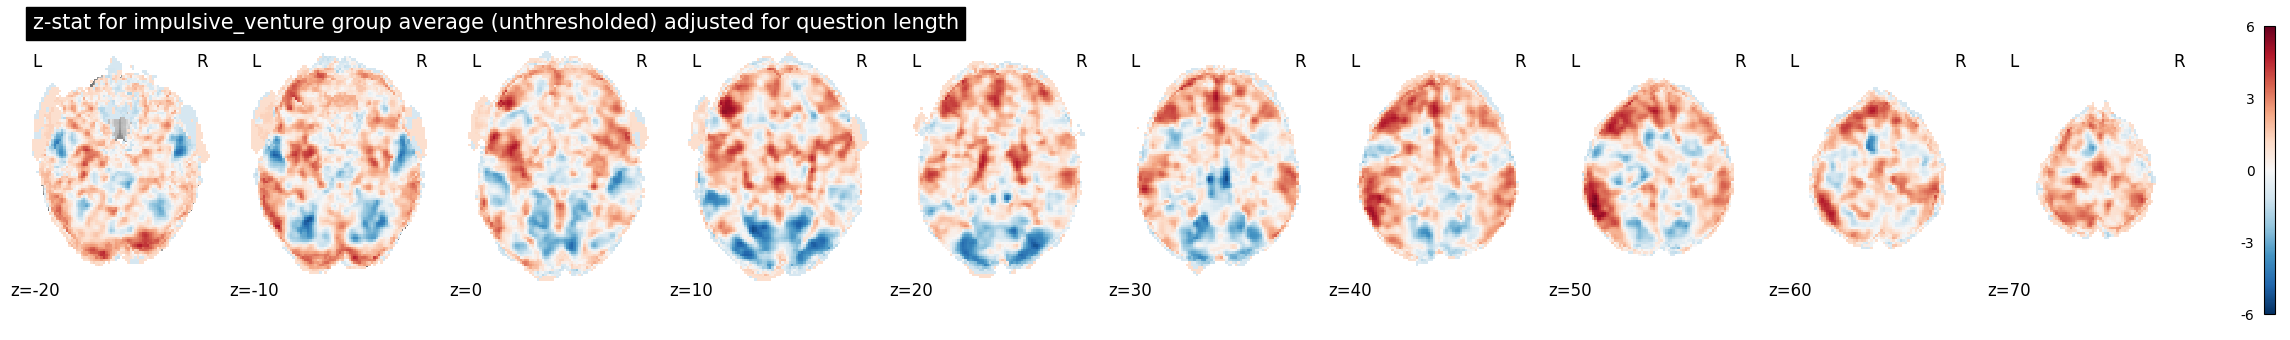

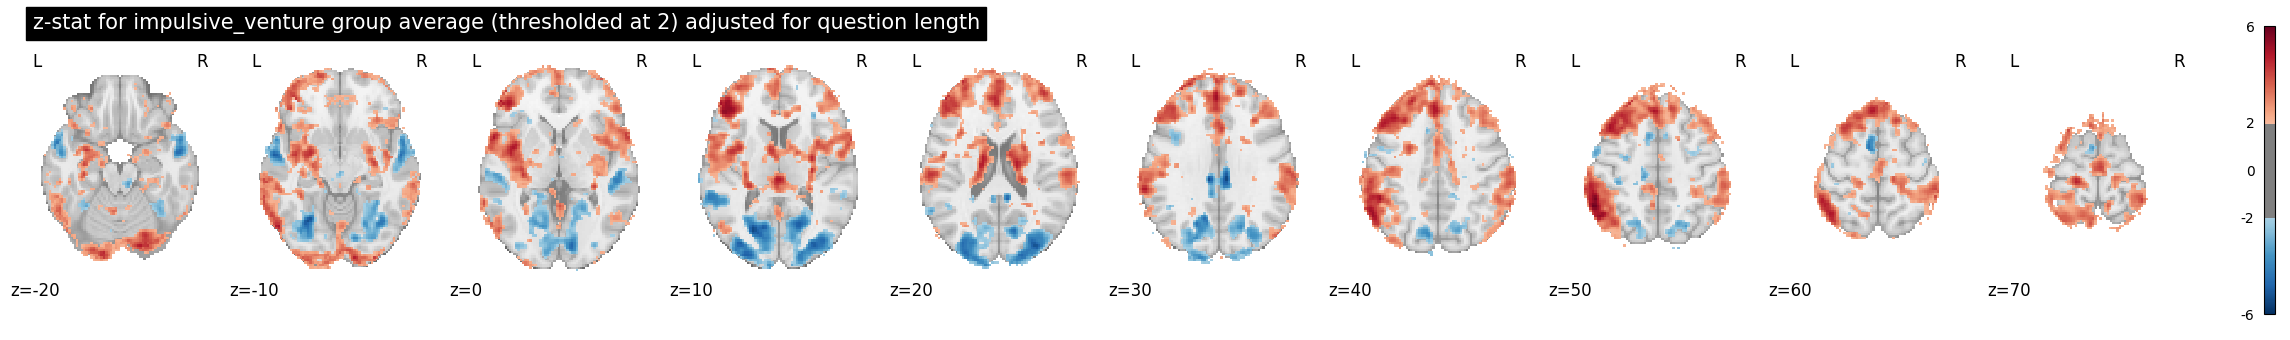

In [11]:
nifti_files = glob.glob('/oak/stanford/groups/russpold/data/uh2/aim1/derivatives/survey_medley_results/within_subject_brain_behavior_by_questionnaire/adjusted_within_subject_results/*/*_behavioral_measures_effect_size*.nii.gz')
contrasts = ["grit", "brief", "future_time", "upps", "impulsive_venture"]
z_slices = [-20, -10, 0, 10, 20, 30, 40, 50, 60, 70]

# run the group average for each contrast and plot the result
for contrast in contrasts:
  # exclude contrasts past threshold of > 8% voxels above +/- 3SD above subject-specific mean
  good_sub_file = outlier_root / f'subjects_outlier_percent_lt_8_contrast_{contrast}.txt'
  sub_ids = good_sub_file.read_text().splitlines()
  
  subject_contrasts = [file for file in nifti_files if any(sub_id in file for sub_id in sub_ids)]

  z_map = second_level_model_group_averages(subject_contrasts, contrast)
  nf.save(z_map, f"/oak/stanford/groups/russpold/data/uh2/aim1/derivatives/survey_medley_results/within_subject_brain_behavior_by_questionnaire/{contrast}_group_average/adjusted_{contrast}_group_average.nii.gz")
  plotting.plot_stat_map(
            z_map,
            display_mode='z',
            cut_coords=z_slices,
            colorbar=True,
            title=f'z-stat for {contrast} group average (unthresholded) adjusted for question length'
        )
  plotting.show()
  plotting.plot_stat_map(
            z_map,
            display_mode='z',
            cut_coords=z_slices,
            colorbar=True,
            threshold=2.0, 
            title=f'z-stat for {contrast} group average (thresholded at 2) adjusted for question length'
        )
  plotting.show()
  
  
  